In [3]:
import pandas as pd

df = pd.read_csv('cafe_sales (1).csv')
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023


## Data Processing and Cleaning

In [4]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB

Missing values per column:
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

Number of duplicate rows:
0


In [5]:
# Convert numeric columns
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [6]:
#Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9667 non-null   object        
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   object        
 6   Location          6735 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [8]:
#Handle missing values
df.fillna({'Payment Method': 'Unknown'}, inplace=True)
df.fillna({'Location': 'Unknown'}, inplace=True)
df.fillna({'Item': 'Unknown item'}, inplace=True)
df.fillna({'Transaction Date': 'pd.NaT'}, inplace=True)


In [9]:
#Handle missing value in the quantity and price per unit columns
df = df.dropna(subset=['Quantity', 'Price Per Unit'])

In [10]:
#Handle missing value in the item, quantity and price per unit columns
df = df.dropna(subset=['Item', 'Quantity', 'Price Per Unit'], how='all')

In [11]:
#Create Calculated total
df['Calculated_Total'] = df['Quantity'] * df['Price Per Unit']

In [12]:
#Verify if calculated total is equal to Total spent
df['Total Spent'] != df['Calculated_Total']

,0
0,False
1,False
2,True
3,False
4,False
...,...
9993,True
9994,False
9995,False
9997,False


In [13]:
#Handle missing value in column Total spent
df.loc[df['Total Spent'].isnull(), 'Total Spent'] = df['Calculated_Total']

In [14]:
#Recheck missing values to comfirm all values are handled
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0
Calculated_Total,0


In [15]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated_Total
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08 00:00:00,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16 00:00:00,12.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19 00:00:00,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27 00:00:00,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11 00:00:00,4.0
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown,2023-03-31 00:00:00,20.0
6,TXN_4433211,UNKNOWN,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06 00:00:00,9.0
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28 00:00:00,16.0
8,TXN_4717867,Unknown item,5.0,3.0,15.0,Unknown,Takeaway,2023-07-28 00:00:00,15.0
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown,In-store,2023-12-31 00:00:00,20.0


In [16]:
#Identify unique values in categorical columns
print("Unique values in 'Item':")
print(df['Item'].unique())

print("\nUnique values in 'Payment Method':")
print(df['Payment Method'].unique())

print("\nUnique values in 'Location':")
print(df['Location'].unique())

Unique values in 'Item':
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich'
 'Unknown item' 'ERROR' 'Juice' 'Tea']

Unique values in 'Payment Method':
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' 'Unknown']

Unique values in 'Location':
['Takeaway' 'In-store' 'UNKNOWN' 'Unknown' 'ERROR']


In [17]:
# Replace invalid values
print(f"DataFrame shape before replacement: {df.shape}")

df['Item'] = df['Item'].replace(['ERROR', 'UNKNOWN'], 'Unknown item')
df['Payment Method'] = df['Payment Method'].replace(['ERROR', 'UNKNOWN'], 'Unknown')
df['Location'] = df['Location'].replace(['ERROR', 'UNKNOWN'], 'Unknown')

print(f"DataFrame shape after replacement: {df.shape}")

print("\nUnique values in 'Item' after replacement:")
print(df['Item'].unique())

print("\nUnique values in 'Payment Method' after replacement:")
print(df['Payment Method'].unique())

print("\nUnique values in 'Location' after replacement:")
print(df['Location'].unique())

DataFrame shape before replacement: (9006, 9)
DataFrame shape after replacement: (9006, 9)

Unique values in 'Item' after replacement:
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Unknown item' 'Sandwich'
 'Juice' 'Tea']

Unique values in 'Payment Method' after replacement:
['Credit Card' 'Cash' 'Unknown' 'Digital Wallet']

Unique values in 'Location' after replacement:
['Takeaway' 'In-store' 'Unknown']


In [18]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Calculated_Total
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08 00:00:00,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16 00:00:00,12.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19 00:00:00,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27 00:00:00,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11 00:00:00,4.0
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Unknown,2023-03-31 00:00:00,20.0
6,TXN_4433211,Unknown item,3.0,3.0,9.0,Unknown,Takeaway,2023-10-06 00:00:00,9.0
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Unknown,2023-10-28 00:00:00,16.0
8,TXN_4717867,Unknown item,5.0,3.0,15.0,Unknown,Takeaway,2023-07-28 00:00:00,15.0
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Unknown,In-store,2023-12-31 00:00:00,20.0


In [19]:
print("\nDescriptive Statistics:")
print(df.describe(include='all'))


Descriptive Statistics:
       Transaction ID   Item     Quantity  Price Per Unit  Total Spent  \
count            9006   9006  9006.000000     9006.000000  9006.000000   
unique           9006      9          NaN             NaN          NaN   
top       TXN_6170729  Juice          NaN             NaN          NaN   
freq                1   1063          NaN             NaN          NaN   
mean              NaN    NaN     3.023540        2.951865     8.936098   
std               NaN    NaN     1.418644        1.277659     5.994375   
min               NaN    NaN     1.000000        1.000000     1.000000   
25%               NaN    NaN     2.000000        2.000000     4.000000   
50%               NaN    NaN     3.000000        3.000000     8.000000   
75%               NaN    NaN     4.000000        4.000000    12.000000   
max               NaN    NaN     5.000000        5.000000    25.000000   

       Payment Method Location Transaction Date  Calculated_Total  
count            9

## Analyze Sales Performance

In [20]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

#Create new columns to analyze trends
df['Month'] = df['Transaction Date'].dt.to_period('M')
df['Day'] = df['Transaction Date'].dt.day_name()
df['Year'] = df['Transaction Date'].dt.year

In [21]:
# Calculate overall total sales
total_sales = df['Total Spent'].sum()
print(f"Overall Total Sales: ${total_sales:,.2f}")

Overall Total Sales: $80,478.50


In [22]:
# Calculate average transaction value
unique_transactions = df['Transaction ID'].nunique()
average_transaction_value = total_sales / unique_transactions
print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

Average Transaction Value: $8.94


In [23]:
# Identify highest revenue items
highest_items = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
print("\nHighest Revenue Items:")
print(highest_items)


Highest Revenue Items:
Item
Salad           15600.0
Sandwich        12296.0
Smoothie        12132.0
Juice            9561.0
Cake             9540.0
Unknown item     7596.5
Coffee           6424.0
Tea              4431.0
Cookie           2898.0
Name: Total Spent, dtype: float64


In [24]:
product_revenue= (highest_items.cumsum() / highest_items.sum()) * 100
product_revenue.head()

,Total Spent
Item,
Salad,19.384059
Sandwich,34.662674
Smoothie,49.737508
Juice,61.617699
Cake,73.471797


In [25]:
# Identify top 5 best-selling items by Quantity
top_5_by_quantity = df.groupby('Item')['Quantity'].sum().nlargest(5)
print("\nTop 5 Best-Selling Items by Quantity:")
print(top_5_by_quantity)


Top 5 Best-Selling Items by Quantity:
Item
Coffee      3212.0
Juice       3187.0
Cake        3180.0
Salad       3120.0
Sandwich    3074.0
Name: Quantity, dtype: float64


In [26]:
#Revenue by Payment Method
Revenue_pm = df.groupby('Payment Method')['Calculated_Total'].sum().sort_values(ascending=False)
print("\nRevenue By Payment Method")
print(Revenue_pm)


Revenue By Payment Method
Payment Method
Unknown           25021.5
Digital Wallet    18530.0
Cash              18486.0
Credit Card       18441.0
Name: Calculated_Total, dtype: float64


In [27]:
#Revenue by Location
revenue_byloca = df.groupby('Location')['Calculated_Total'].sum().sort_values(ascending=False)
print("\nRevenue By Location")
print(revenue_byloca)


Revenue By Location
Location
Unknown     32012.5
In-store    24598.0
Takeaway    23868.0
Name: Calculated_Total, dtype: float64


In [ ]:
#Average per row
Aveg_per_row = df['Calculated_Total'].mean()
print("\nAverage Per row:")
print(Aveg_per_row)
#Compare by Location
df.groupby('Location')['Calculated_Total'].mean().sort_values(ascending=False)


Average Per row:
8.936098156784366


,Calculated_Total
Location,
Unknown,9.046753
In-store,9.006957
ERROR,8.969136
Takeaway,8.804131
UNKNOWN,8.361204


In [28]:
#Sales Growth Rate (Month-over-Month)
monthly = df.groupby('Month')['Calculated_Total'].sum()
monthly.pct_change() * 100
print("\nSales Growth Rate (Month-over-Month):")
print(monthly.pct_change() * 100)


Sales Growth Rate (Month-over-Month):
Month
2023-01         NaN
2023-02   -6.160403
2023-03    7.052023
2023-04    0.053996
2023-05   -4.540899
2023-06    7.866257
2023-07   -4.664570
2023-08    1.358674
2023-09   -3.773439
2023-10    4.871568
2023-11   -1.443489
2023-12   -0.475226
Freq: M, Name: Calculated_Total, dtype: float64


In [29]:
#Average Quantity per Transaction
df['Quantity'].mean()
print("\nAverage Quantity per Transaction:")
print(df['Quantity'].mean())


Average Quantity per Transaction:
3.023539862314013


## Visualize Insights

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

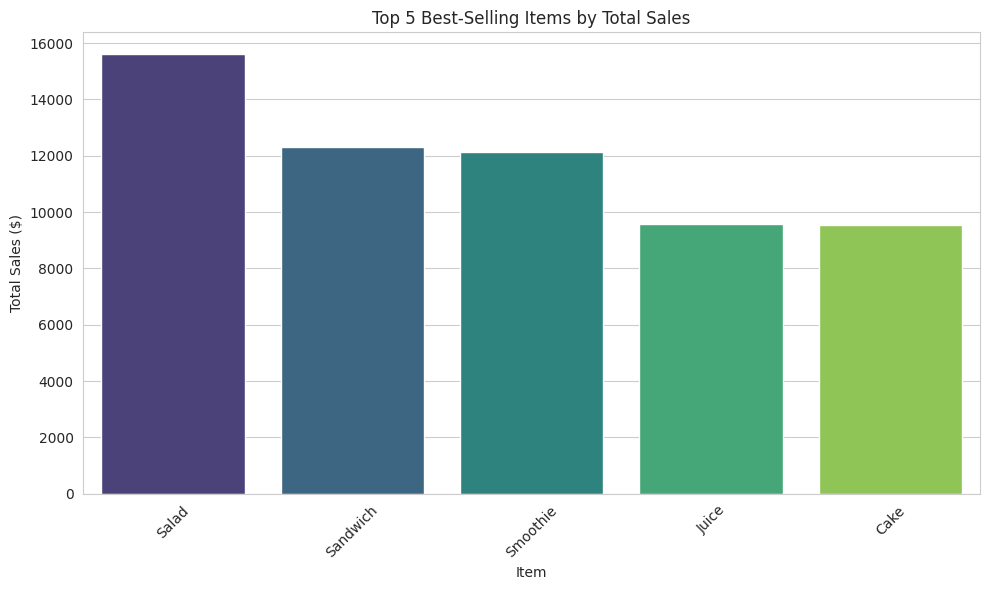

In [31]:
# Set plot style
sns.set_style("whitegrid")

# Bar chart for Top 5 Best-Selling Items by Total Spent
plt.figure(figsize=(10, 6))
top_5_by_spent = highest_items.head(5)
sns.barplot(x=top_5_by_spent.index, y=top_5_by_spent.values, hue=top_5_by_spent.index, palette='viridis', legend=False)
plt.title('Top 5 Best-Selling Items by Total Sales')
plt.xlabel('Item')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

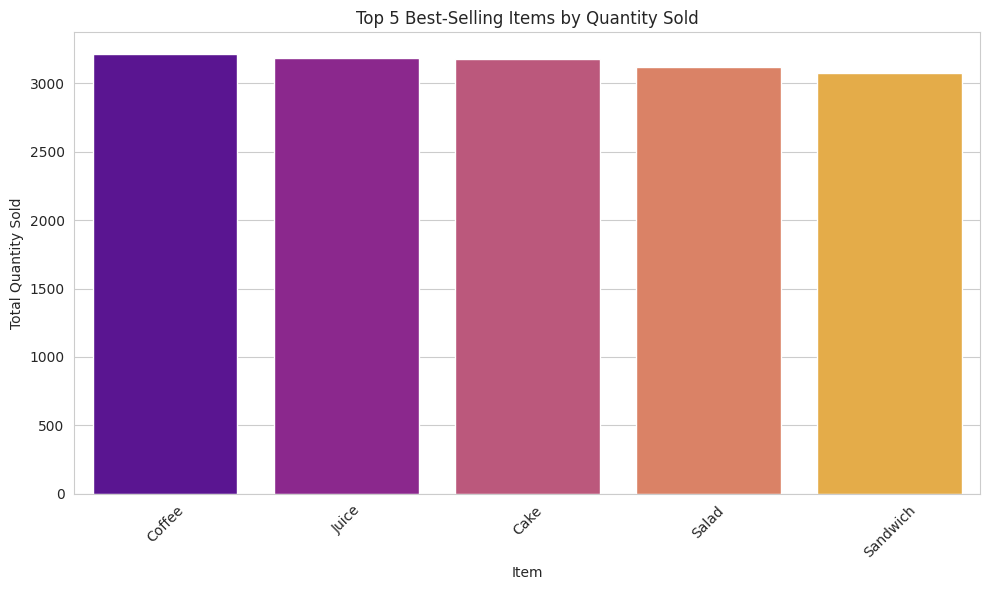

In [32]:
# Bar chart for Top 5 Best-Selling Items by Quantity
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_by_quantity.index, y=top_5_by_quantity.values, hue=top_5_by_quantity.index, palette='plasma', legend=False)
plt.title('Top 5 Best-Selling Items by Quantity Sold')
plt.xlabel('Item')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
#Prepare data for sales trend plot: Group by 'Transaction Date' and sum 'Total Spent'
daily_sales = df.groupby('Transaction Date')['Total Spent'].sum().reset_index()
daily_sales = daily_sales.sort_values(by='Transaction Date')

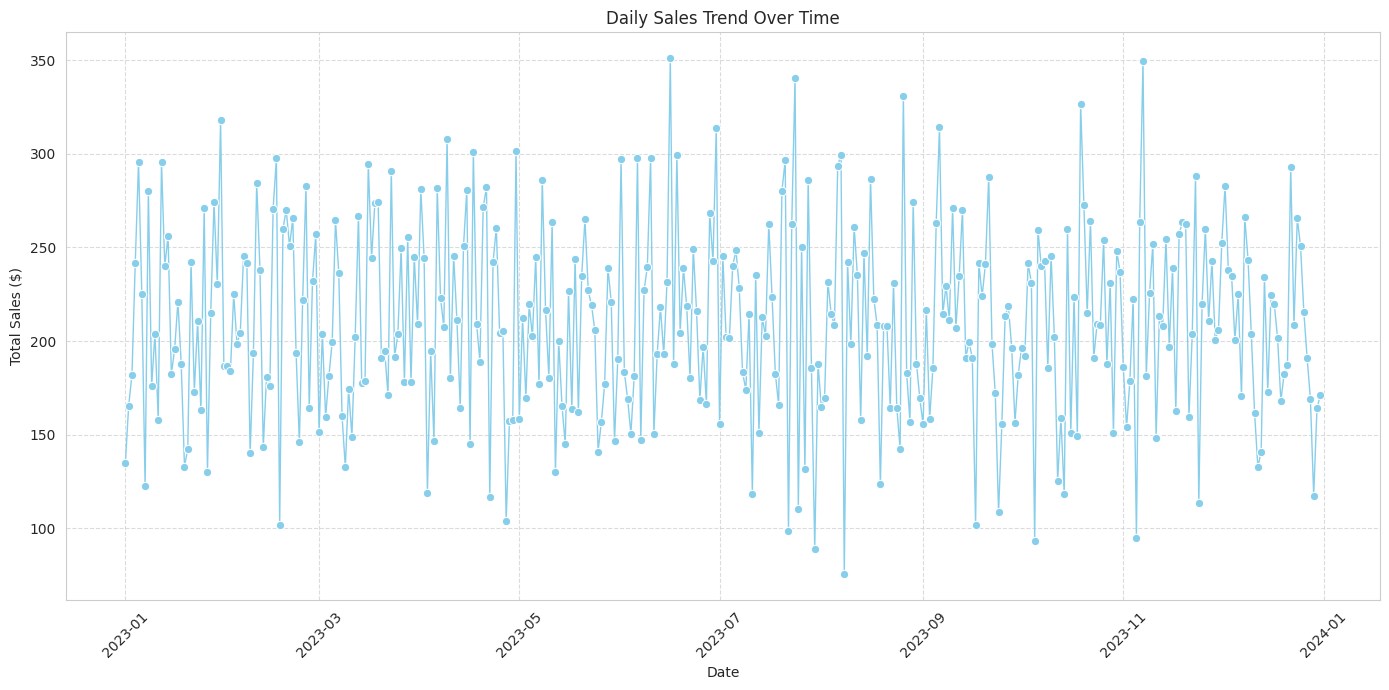

In [34]:
#Line plot for Daily Sales Trend Over Time
plt.figure(figsize=(14, 7))
sns.lineplot(x=daily_sales['Transaction Date'], y=daily_sales['Total Spent'], marker='o', linestyle='-', color='skyblue', linewidth=1)
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

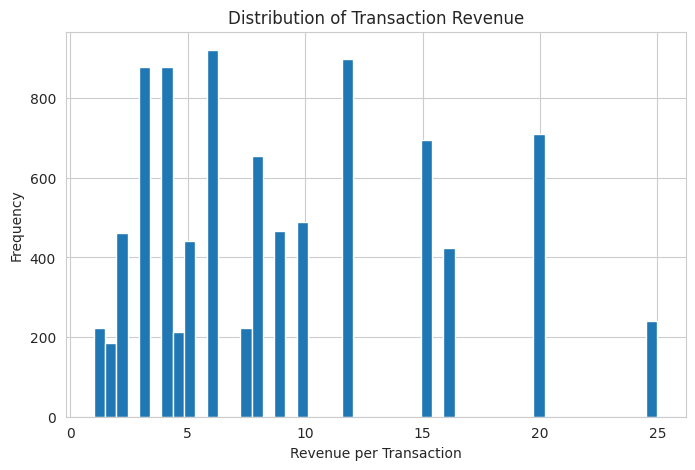

In [35]:
#Histogram showing Revenue Distribution Analysis
plt.figure(figsize=(8,5))
plt.hist(df['Calculated_Total'], bins=50)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue per Transaction")
plt.ylabel("Frequency")
plt.show()

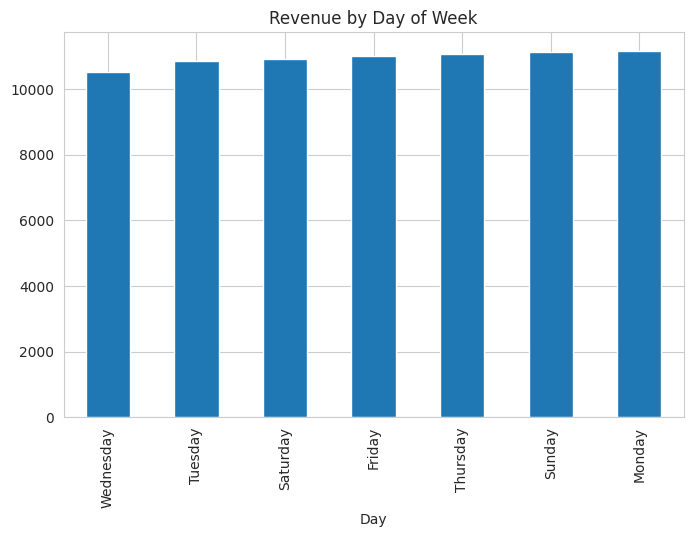

In [36]:
#Bar chart for Revenue by Day of Week
day_sales = df.groupby('Day')['Calculated_Total'].sum().sort_values()

day_sales.plot(kind='bar', figsize=(8,5))
plt.title("Revenue by Day of Week")
plt.show()

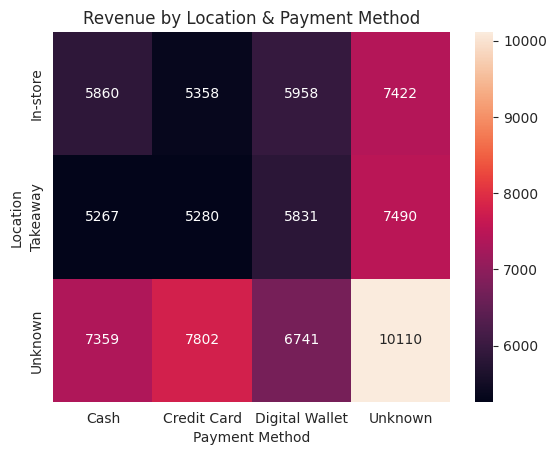

In [37]:
#Heatmap for Revenue by Location × Payment Method (Cross Analysis)
pivot = df.pivot_table(
    values='Calculated_Total',
    index='Location',
    columns='Payment Method',
    aggfunc='sum'
)

sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Revenue by Location & Payment Method")
plt.show()

Key Findings

1. The café generated $80,478.50 in total revenue.

2. The average transaction value is $8.94, with an average of 3 items per purchase.
3. Highest Revenue-Generating Items:

* Salad — $15,600

* Sandwich — $12,296

* Smoothie — $12,132

* Juice — $9,561

* Cake — $9,540

4. Top 5 best-selling items by quantity:

* Coffee — 3,212 units

* Juice — 3,187 units

* Cake — 3,180 units

* Salad — 3,120 units

* Sandwich — 3,074 units

5. Revenue by Payment Method:
* Unknown — $20,314.50,

* Digital Wallet — $18,530

* Cash — $18,486

* Credit Card — $18,441

6. Revenue Distribution

Minimum transaction: $1

Maximum transaction: $25

Median transaction: $8

Mean transaction: $8.94